# Nontidal predictors of tidal Enterococcus

Blue Water Baltimore AWQMP, 2013-2024. Added predictive value of upstream stream data
(Gwynns Falls BWB-GWN, Jones Falls BWB-JON) over a harbor-only baseline for Enterococcus
at the tidal harbor (BWB-PATMH, Patapsco).

Feature sets, compared on identical samples and year-blocked folds:
`T1` harbor in-situ WQ; `T2` = T1 + upstream stream data; `T3` upstream data only.

## Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch
from scipy import stats
import statsmodels.api as sm
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
)
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    roc_auc_score,
    average_precision_score,
)
from IPython.display import display

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
XL = DATA_DIR / "BWB_AWQMP_Data_2009-2024-analyse061026.xlsx"

THRESH = 104.0        # single-sample recreational exceedance, MPN/100 mL
JOIN_TOL = 7          # days: window for matching a harbor sample to a stream survey
RANDOM_STATE = 42

# figure colors
HARBOR = "#2a78d6"
STREAM = "#e6602c"
SITE = "#7c8a85"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

if not XL.exists():
    raise FileNotFoundError(f"Place the workbook at {XL} (see README).")
print("Workbook:", XL)

Workbook: data/BWB_AWQMP_Data_2009-2024-analyse061026.xlsx


## Load and harmonize target

In [2]:
def clean_bacteria(series):
    """Parse Enterococcus values, including censored <10 / >24196, to numeric MPN."""
    def parse(value):
        if pd.isna(value):
            return np.nan
        if isinstance(value, (int, float)):
            return float(value)
        text = str(value).strip().replace(",", "")
        if text.startswith("<"):
            return float(text[1:]) / 2.0     # below detection: half the limit
        if text.startswith(">"):
            return float(text[1:])           # above range: the reporting limit
        try:
            return float(text)
        except ValueError:
            return np.nan
    return series.map(parse)


def to_date(series):
    """Excel serial numbers or datetime strings -> normalized dates."""
    if np.issubdtype(series.dtype, np.number):
        return pd.to_datetime(series, unit="D", origin="1899-12-30").dt.normalize()
    return pd.to_datetime(series, errors="coerce").dt.normalize()


def harmonize(a2la, bwb):
    """Fill missing A2LA readings with the BWB reading placed on the A2LA scale."""
    bwb_equiv = 10 ** (-0.0424 + 0.7830 * np.log10(bwb + 1)) - 1
    return a2la.where(a2la.notna(), bwb_equiv)


def load_sheet(sheet):
    df = pd.read_excel(XL, sheet_name=sheet)
    df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]
    df["date"] = to_date(df["Collection Date"])
    df["prefix"] = df["Station ID"].astype(str).str.extract(r"(BWB-[A-Z]+)")
    a2la = clean_bacteria(df["Enterococcus Bacteria (MPN/100mL) - A2LA Lab"])
    bwb = clean_bacteria(df["Enterococcus Bacteria (MPN/100mL) - BWB Lab"])
    df["entero"] = harmonize(a2la, bwb)
    return df


tidal = load_sheet("BWB Tidal Data 2009-2024")
nt = load_sheet("BWB Nontidal Data 2013-2024")

print("Tidal harbor samples with target:   ", tidal["entero"].notna().sum())
print("Nontidal stream samples with target:", nt["entero"].notna().sum(),
      "(GWN", (nt["prefix"] == "BWB-GWN").sum(),
      "JON", (nt["prefix"] == "BWB-JON").sum(), ")")

Tidal harbor samples with target:    3581
Nontidal stream samples with target: 3561 (GWN 1923 JON 1800 )


## Harbor surface profile

In [3]:
tp = pd.read_excel(XL, sheet_name="BWB Tidal Profiles 2013-2024")
tp["date"] = to_date(tp["Collection Date"])

prof_cols = [
    "Temperature (°C)",
    "pH (SU)",
    "Specific Conductance (µS/cm)",
    "Salinity (ppt)",
    "Dissolved Oxygen (mg/L)",
]

# shallowest reading per station/date = the surface value
surface = (
    tp.sort_values("Reading Depth (m)")
      .groupby(["Station ID", "date"], as_index=False)
      .first()[["Station ID", "date"] + prof_cols]
)
tidal = tidal.merge(surface, on=["Station ID", "date"], how="left")

matched_frac = tidal["Temperature (°C)"].notna().mean()
print(f"Harbor samples matched to a surface profile: {matched_frac:.0%}")

Harbor samples matched to a surface profile: 67%


## Upstream stream features

In [4]:
NT_CHEM = {
    "Turbidity (NTU)": "turb",
    "Total Phosphorus (mg/L)": "tp",
    "Dissolved Oxygen (mg/L)": "do",
    "Nitrate/Nitrite (mg/L)": "no23",
    "Specific Conductance (µS/cm)": "cond",
    "Temperature (°C)": "temp",
}

streams = nt.copy()
streams["log_entero"] = np.log10(streams["entero"] + 1)
for col in NT_CHEM:
    streams[col] = pd.to_numeric(streams[col], errors="coerce")


def daily_agg(df, label):
    """Collapse a set of stream stations to one row per date."""
    grouped = df.groupby("date")
    out = pd.DataFrame({
        f"{label}_entero_mean": grouped["log_entero"].mean(),
        f"{label}_entero_max": grouped["log_entero"].max(),
    })
    for col, short in NT_CHEM.items():
        out[f"{label}_{short}"] = grouped[col].mean()
    return out.reset_index()


agg_all = daily_agg(streams, "ntALL")
agg_gwn = daily_agg(streams[streams["prefix"] == "BWB-GWN"], "ntGWN")[
    ["date", "ntGWN_entero_mean", "ntGWN_entero_max"]
]
agg_jon = daily_agg(streams[streams["prefix"] == "BWB-JON"], "ntJON")[
    ["date", "ntJON_entero_mean", "ntJON_entero_max"]
]

nt_daily = (
    agg_all
    .merge(agg_gwn, on="date", how="outer")
    .merge(agg_jon, on="date", how="outer")
    .sort_values("date")
)
NT_FEATURES = [c for c in nt_daily.columns if c != "date"]
print(len(NT_FEATURES), "upstream features:", NT_FEATURES)

12 upstream features: ['ntALL_entero_mean', 'ntALL_entero_max', 'ntALL_turb', 'ntALL_tp', 'ntALL_do', 'ntALL_no23', 'ntALL_cond', 'ntALL_temp', 'ntGWN_entero_mean', 'ntGWN_entero_max', 'ntJON_entero_mean', 'ntJON_entero_max']


## Temporal join (nearest survey within 7 days)

In [5]:
tidal = tidal.sort_values("date")

merged = pd.merge_asof(
    tidal,
    nt_daily.rename(columns={"date": "nt_date"}),
    left_on="date",
    right_on="nt_date",
    direction="nearest",
    tolerance=pd.Timedelta(f"{JOIN_TOL}D"),
)
merged["nt_lag_days"] = (merged["date"] - merged["nt_date"]).dt.days
merged["has_nt"] = merged["ntALL_entero_mean"].notna()


def add_context(df):
    """Add season (month sine/cosine), year, and per-station indicator columns."""
    df = df.copy()
    df["month"] = df["date"].dt.month
    df["msin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["mcos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["year"] = df["date"].dt.year
    for station in sorted(df["Station ID"].astype(str).unique()):
        df[f"site_{station}"] = (df["Station ID"].astype(str) == station).astype(int)
    return df


merged = add_context(merged)
matched = merged[merged["has_nt"]].copy()   # harbor samples with an upstream match

with_target = merged[merged["entero"].notna()]
coverage = with_target["has_nt"].mean()
median_lag = with_target.loc[with_target["has_nt"], "nt_lag_days"].abs().median()
print(f"Harbor samples: {len(with_target)}")
print(f"With an upstream match within {JOIN_TOL} days: {coverage:.0%} "
      f"(median lag {median_lag:.0f} d)")

Harbor samples: 3581
With an upstream match within 7 days: 87% (median lag 1 d)


## Feature sets and year-blocked CV

In [6]:
CONTEXT = ["msin", "mcos", "Latitude", "Longitude"]
TIDAL_INSITU = [
    "Total Water Depth (ft)",
    "Nitrate/Nitrite (mg/L)",
    "Total Nitrogen (mg/L)",
    "Total Phosphorus (mg/L)",
    "Total Kjeldahl Nitrogen (mg/L)",
    "Chlorophyll (µg/L)",
    "Secchi Depth (m)",
] + prof_cols


def feature_sets():
    return {
        "T0 Context": CONTEXT,
        "T1 + Harbor in-situ WQ": CONTEXT + TIDAL_INSITU,
        "T2 + Nontidal data": CONTEXT + TIDAL_INSITU + NT_FEATURES,
        "T3 Nontidal only": CONTEXT + NT_FEATURES,
    }


def build_models(model, seed):
    if model == "rf":
        reg = RandomForestRegressor(300, min_samples_leaf=3, n_jobs=-1, random_state=seed)
        clf = RandomForestClassifier(300, min_samples_leaf=3, n_jobs=-1,
                                     random_state=seed, class_weight="balanced")
    else:
        reg = GradientBoostingRegressor(random_state=seed)
        clf = GradientBoostingClassifier(random_state=seed)
    return reg, clf


def evaluate(df, features, model="rf", n_splits=5, seed=RANDOM_STATE):
    """Year-blocked out-of-fold scores for one feature set."""
    data = df[df["entero"].notna()].copy()
    site_cols = [c for c in data.columns if c.startswith("site_")]
    cols = features + site_cols

    X = data[cols].apply(pd.to_numeric, errors="coerce").astype(float).values
    y_reg = np.log10(data["entero"].values + 1.0)
    y_cls = (data["entero"].values > THRESH).astype(int)
    groups = data["year"].values

    oof_reg = np.full(len(data), np.nan)
    oof_prob = np.full(len(data), np.nan)
    for train, test in GroupKFold(n_splits=n_splits).split(X, y_reg, groups):
        # median-impute using the training fold only
        med = np.nanmedian(X[train], axis=0)
        med = np.where(np.isnan(med), 0, med)
        X_train = np.where(np.isnan(X[train]), med, X[train])
        X_test = np.where(np.isnan(X[test]), med, X[test])

        reg, clf = build_models(model, seed)
        oof_reg[test] = reg.fit(X_train, y_reg[train]).predict(X_test)
        oof_prob[test] = clf.fit(X_train, y_cls[train]).predict_proba(X_test)[:, 1]

    return {
        "R2": r2_score(y_reg, oof_reg),
        "RMSE": np.sqrt(mean_squared_error(y_reg, oof_reg)),
        "AUC": roc_auc_score(y_cls, oof_prob),
        "PR_AUC": average_precision_score(y_cls, oof_prob),
        "n": len(data),
        "exc": y_cls.mean(),
        "y_cls": y_cls,
        "oof_p": oof_prob,
    }

## Results

In [7]:
def comparison(df, model="rf"):
    results = {name: evaluate(df, feats, model=model)
               for name, feats in feature_sets().items()}
    table = pd.DataFrame({
        name: {"R2": r["R2"], "RMSE": r["RMSE"], "AUC": r["AUC"], "PR-AUC": r["PR_AUC"]}
        for name, r in results.items()
    }).T.round(3)
    return table, results


tab_matched, res_matched = comparison(matched)
print(f"Matched subset (n={res_matched['T1 + Harbor in-situ WQ']['n']}, "
      f"exceedance rate {res_matched['T1 + Harbor in-situ WQ']['exc']:.1%})")
display(tab_matched)
lift = tab_matched.loc["T2 + Nontidal data"] - tab_matched.loc["T1 + Harbor in-situ WQ"]
print("Change from adding nontidal data (T2 - T1):", dict(lift.round(3)))

tab_full, res_full = comparison(merged)
print(f"\nFull sample (n={res_full['T1 + Harbor in-situ WQ']['n']}, "
      f"exceedance rate {res_full['T1 + Harbor in-situ WQ']['exc']:.1%})")
display(tab_full)
lift = tab_full.loc["T2 + Nontidal data"] - tab_full.loc["T1 + Harbor in-situ WQ"]
print("Change from adding nontidal data (T2 - T1):", dict(lift.round(3)))

Matched subset (n=3121, exceedance rate 16.6%)


,R2,RMSE,AUC,PR-AUC
T0 Context,0.139,0.918,0.712,0.332
T1 + Harbor in-situ WQ,0.165,0.904,0.746,0.357
T2 + Nontidal data,0.278,0.841,0.802,0.496
T3 Nontidal only,0.224,0.872,0.788,0.450


Change from adding nontidal data (T2 - T1): {'R2': np.float64(0.113), 'RMSE': np.float64(-0.063), 'AUC': np.float64(0.056), 'PR-AUC': np.float64(0.139)}



Full sample (n=3581, exceedance rate 16.1%)


,R2,RMSE,AUC,PR-AUC
T0 Context,0.171,0.903,0.710,0.320
T1 + Harbor in-situ WQ,0.204,0.885,0.745,0.356
T2 + Nontidal data,0.228,0.872,0.798,0.477
T3 Nontidal only,0.163,0.908,0.792,0.441


Change from adding nontidal data (T2 - T1): {'R2': np.float64(0.024), 'RMSE': np.float64(-0.013), 'AUC': np.float64(0.053), 'PR-AUC': np.float64(0.121)}


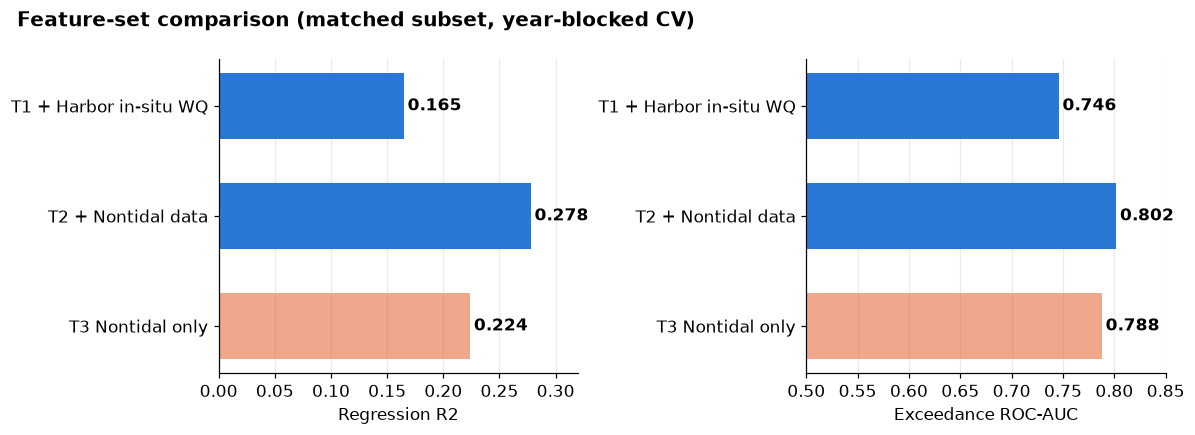

In [8]:
order = ["T1 + Harbor in-situ WQ", "T2 + Nontidal data", "T3 Nontidal only"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

panels = [
    (axes[0], "R2", 0, 0.32, "Regression R2"),
    (axes[1], "AUC", 0.5, 0.85, "Exceedance ROC-AUC"),
]
for ax, metric, lo, hi, xlabel in panels:
    values = tab_matched.loc[order, metric]
    for i, (name, value) in enumerate(values.items()):
        color = STREAM if name == "T3 Nontidal only" else HARBOR
        ax.barh(i, value, color=color, alpha=[1, 1, 0.55][i], height=0.6)
        ax.text(value + (hi - lo) * 0.01, i, f"{value:.3f}", va="center", fontweight="bold")
    ax.set_yticks(range(3))
    ax.set_yticklabels(order)
    ax.invert_yaxis()
    ax.set_xlim(lo, hi)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", alpha=0)

fig.suptitle("Feature-set comparison (matched subset, year-blocked CV)",
             x=0.02, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

## Dose-response

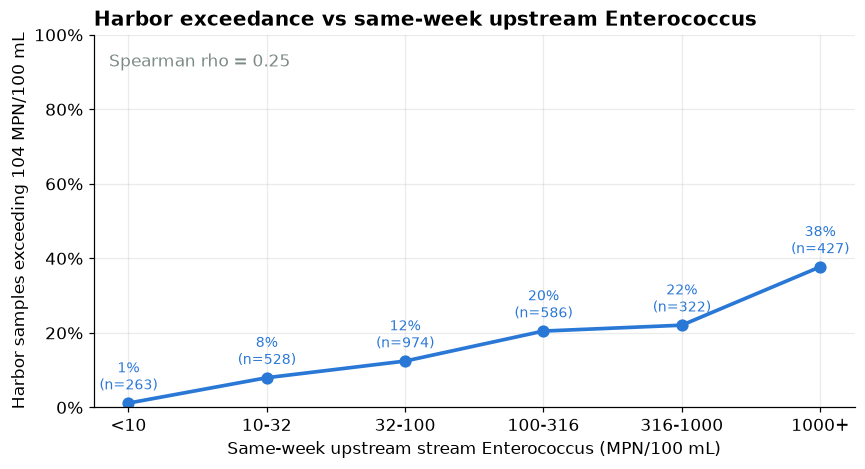

In [9]:
dose = matched[matched["entero"].notna()].copy()
dose["exceed"] = (dose["entero"] > THRESH).astype(int)
dose["upstream"] = pd.to_numeric(dose["ntALL_entero_mean"], errors="coerce")

bins = [0, 1, 1.5, 2, 2.5, 3, 5]
labels = ["<10", "10-32", "32-100", "100-316", "316-1000", "1000+"]
dose["bin"] = pd.cut(dose["upstream"], bins=bins, labels=labels)
grouped = dose.groupby("bin", observed=True)["exceed"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(range(len(grouped)), grouped["mean"] * 100, "-o", color=HARBOR, lw=2.4, ms=7)
for i, (share, count) in enumerate(zip(grouped["mean"], grouped["count"])):
    ax.annotate(f"{share * 100:.0f}%\n(n={count})", (i, share * 100),
                textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9, color=HARBOR)
ax.set_xticks(range(len(grouped)))
ax.set_xticklabels(list(grouped.index))
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylabel("Harbor samples exceeding 104 MPN/100 mL")
ax.set_xlabel("Same-week upstream stream Enterococcus (MPN/100 mL)")
ax.set_title("Harbor exceedance vs same-week upstream Enterococcus",
             loc="left", fontweight="bold")

rho = stats.spearmanr(dose["upstream"], np.log10(dose["entero"] + 1),
                      nan_policy="omit").correlation
ax.text(0.02, 0.95, f"Spearman rho = {rho:.2f}", transform=ax.transAxes,
        va="top", color=SITE)
plt.tight_layout()
plt.show()

## Feature importance

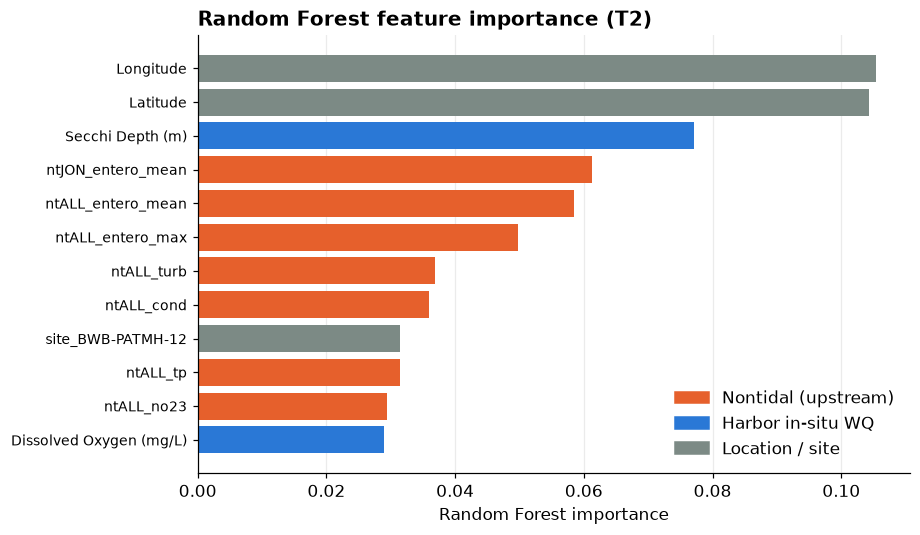

In [10]:
imp_data = matched[matched["entero"].notna()].copy()
site_cols = [c for c in imp_data.columns if c.startswith("site_")]
cols = feature_sets()["T2 + Nontidal data"] + site_cols

X = imp_data[cols].apply(pd.to_numeric, errors="coerce").astype(float)
X = X.fillna(X.median())
y = np.log10(imp_data["entero"] + 1)

rf = RandomForestRegressor(400, min_samples_leaf=3, n_jobs=-1, random_state=0).fit(X, y)
importance = (
    pd.Series(rf.feature_importances_, index=cols)
    .sort_values(ascending=False)
    .head(12)[::-1]
)


def feature_color(name):
    if name in NT_FEATURES:
        return STREAM
    if name.startswith("site_") or name in ("Latitude", "Longitude"):
        return SITE
    return HARBOR


fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(range(len(importance)), importance.values,
        color=[feature_color(n) for n in importance.index])
ax.set_yticks(range(len(importance)))
ax.set_yticklabels(importance.index, fontsize=9)
ax.grid(axis="y", alpha=0)
ax.set_xlabel("Random Forest importance")
ax.set_title("Random Forest feature importance (T2)", loc="left", fontweight="bold")
ax.legend(handles=[
    Patch(color=STREAM, label="Nontidal (upstream)"),
    Patch(color=HARBOR, label="Harbor in-situ WQ"),
    Patch(color=SITE, label="Location / site"),
], frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

## Statistical tests and robustness

In [11]:
stat = matched[matched["entero"].notna()].copy()
base_features = CONTEXT + TIDAL_INSITU
add_features = list(NT_FEATURES)

for col in base_features + add_features:
    stat[col] = pd.to_numeric(stat[col], errors="coerce")
stat[base_features + add_features] = (
    stat[base_features + add_features].fillna(stat[base_features + add_features].median())
)

year_fe = pd.get_dummies(stat["year"].astype(int), prefix="yr", drop_first=True).astype(float)
y_log = np.log10(stat["entero"] + 1).values
y_exc = (stat["entero"] > THRESH).astype(int).values

X_base = sm.add_constant(pd.concat(
    [stat[base_features].reset_index(drop=True), year_fe.reset_index(drop=True)], axis=1
).astype(float))
X_full = sm.add_constant(pd.concat(
    [stat[base_features + add_features].reset_index(drop=True), year_fe.reset_index(drop=True)],
    axis=1,
).astype(float))
k = len(add_features)

# OLS partial-F test on the added upstream block
ols_base = sm.OLS(y_log, X_base).fit()
ols_full = sm.OLS(y_log, X_full).fit()
df_resid = int(ols_full.df_resid)
F = ((ols_base.ssr - ols_full.ssr) / k) / (ols_full.ssr / df_resid)
p_F = 1 - stats.f.cdf(F, k, df_resid)
print(f"OLS   log10(Entero): adj R2 {ols_base.rsquared_adj:.3f} -> {ols_full.rsquared_adj:.3f}"
      f" | partial-F({k},{df_resid}) = {F:.1f}, p = {p_F:.2g}")

# Logistic likelihood-ratio test on exceedance
logit_base = sm.Logit(y_exc, X_base).fit(disp=0)
logit_full = sm.Logit(y_exc, X_full).fit(disp=0)
LR = 2 * (logit_full.llf - logit_base.llf)
p_LR = 1 - stats.chi2.cdf(LR, k)
print(f"Logit exceed>104:   pseudo-R2 {logit_base.prsquared:.3f} -> {logit_full.prsquared:.3f}"
      f" | LR chi2({k}) = {LR:.0f}, p = {p_LR:.2g}")

# robustness: repeat the T2 - T1 gain across seeds and model types
print("\nGain from nontidal data (T2 - T1), mean +/- sd over seeds:")
sets = feature_sets()
for model in ["rf", "gb"]:
    delta_r2, delta_auc = [], []
    for seed in (0, 1, 2):
        base = evaluate(matched, sets["T1 + Harbor in-situ WQ"], model=model, seed=seed)
        full = evaluate(matched, sets["T2 + Nontidal data"], model=model, seed=seed)
        delta_r2.append(full["R2"] - base["R2"])
        delta_auc.append(full["AUC"] - base["AUC"])
    print(f"  {model.upper()}: dR2 = {np.mean(delta_r2):+.3f} +/- {np.std(delta_r2):.3f}"
          f"   dAUC = {np.mean(delta_auc):+.3f} +/- {np.std(delta_auc):.3f}")

OLS   log10(Entero): adj R2 0.335 -> 0.386 | partial-F(12,3081) = 22.4, p = 0


Logit exceed>104:   pseudo-R2 0.273 -> 0.344 | LR chi2(12) = 200, p = 0

Gain from nontidal data (T2 - T1), mean +/- sd over seeds:


  RF: dR2 = +0.116 +/- 0.001   dAUC = +0.057 +/- 0.001


  GB: dR2 = +0.072 +/- 0.001   dAUC = +0.057 +/- 0.001


## Streamflow (pending daily USGS data)

In [12]:
GAUGE_TO_WATERSHED = {1589300: "Gwynns", 1589440: "Jones"}
STREAMFLOW_DAILY = None   # set to the daily discharge CSV path when available


def build_flow_features(daily):
    """Antecedent-flow features per gauge from a daily discharge table."""
    daily = daily.copy()
    daily["date"] = pd.to_datetime(daily["date"]).dt.normalize()

    parts = []
    for site_no, group in daily.groupby("site_no"):
        group = group.sort_values("date").set_index("date")
        q = pd.to_numeric(group["discharge_cfs"], errors="coerce")
        q = q.reindex(pd.date_range(q.index.min(), q.index.max(), freq="D")).interpolate()

        feat = pd.DataFrame(index=q.index)
        feat["q_0d"] = q
        feat["q_1d"] = q.shift(1)
        feat["q_3d"] = q.rolling(3).mean().shift(1)
        feat["q_7d"] = q.rolling(7).mean().shift(1)
        feat["logq"] = np.log10(q + 1)
        feat["q_rise"] = q - q.shift(1)
        parts.append(feat.add_prefix(f"flow{int(site_no)}_").reset_index(names="date"))

    flow = parts[0]
    for part in parts[1:]:
        flow = flow.merge(part, on="date", how="outer")
    return flow


def run_with_streamflow(path=STREAMFLOW_DAILY):
    if path is None:
        print("No daily streamflow yet. Set STREAMFLOW_DAILY to the CSV path and re-run.")
        return
    flow = build_flow_features(pd.read_csv(path))
    joined = pd.merge_asof(
        merged.sort_values("date"),
        flow.sort_values("date").rename(columns={"date": "q_date"}),
        left_on="date", right_on="q_date", direction="nearest",
        tolerance=pd.Timedelta("3D"),
    )
    flow_cols = [c for c in flow.columns if c != "date"]
    base = evaluate(joined, feature_sets()["T2 + Nontidal data"])
    full = evaluate(joined, feature_sets()["T2 + Nontidal data"] + flow_cols)
    print("Adding streamflow to the upstream set:")
    print(f"  R2  {base['R2']:.3f} -> {full['R2']:.3f}"
          f"   AUC {base['AUC']:.3f} -> {full['AUC']:.3f}")


run_with_streamflow()

No daily streamflow yet. Set STREAMFLOW_DAILY to the CSV path and re-run.


## Summary

- Upstream data improves the harbor-only baseline: R2 0.165 -> 0.278, exceedance AUC 0.746 -> 0.802 (matched subset, n=3121).
- Added block significant: OLS partial-F p<0.001; logistic LR chi2 p<0.001; stable across seeds and RF/GB.
- Dominant upstream predictor: stream Enterococcus (Jones Falls). Harbor exceedance ~1% (clean streams) to ~38% (high streams).
- Upstream-only (T3) roughly matches the baseline (AUC 0.788 vs 0.746).
- Rainfall control and daily-streamflow tests pending the respective data.